Importing Essential Libraries

In [1]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install ydata-profiling


  Using cached ydata_profiling-4.18.4-py2.py3-none-any.whl.metadata (23 kB)
Using cached ydata_profiling-4.18.4-py2.py3-none-any.whl (400 kB)
Note: you may need to restart the kernel to use updated packages.


In [1]:
pip show ydata-profiling

Name: ydata-profiling
Version: 4.18.4
Summary: Generate profile report for pandas DataFrame
Home-page: https://ydata.ai
Author: 
Author-email: YData Labs Inc <opensource@ydata.ai>
License: 
Location: /Users/sravanpusuluri/customer-churn-prediction/venv/lib/python3.12/site-packages
Requires: dacite, filetype, imagehash, jinja2, matplotlib, minify-html, multimethod, numba, numpy, pandas, phik, pydantic, PyYAML, requests, scipy, seaborn, statsmodels, tqdm, typeguard, visions, wordcloud
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [6]:
pip install setuptools==69.5.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 894.6/894.6 kB 9.8 MB/s  0:00:00
  Attempting uninstall: setuptools
    Found existing installation: setuptools 82.0.1
    Uninstalling setuptools-82.0.1:
      Successfully uninstalled setuptools-82.0.1
Note: you may need to restart the kernel to use updated packages.


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [27]:
df = pd.read_excel('E Commerce Dataset.xlsx', sheet_name='E Comm')
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [28]:
df.shape

(5630, 20)

In [8]:
from ydata_profiling import ProfileReport

profile=ProfileReport(df, title="Customer Churn Analysis Report", explorative=True)
profile.to_file('churn_report.html')

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 200.76it/s]


In [29]:
col_with_missing_val=['Tenure','WarehouseToHome','HourSpendOnApp','OrderAmountHikeFromlastYear','CouponUsed','OrderCount','DaySinceLastOrder']

for col in col_with_missing_val:
    df[col]=df[col].fillna(df[col].median())

In [30]:
df.isnull().sum()

CustomerID                     0
Churn                          0
Tenure                         0
PreferredLoginDevice           0
CityTier                       0
WarehouseToHome                0
PreferredPaymentMode           0
Gender                         0
HourSpendOnApp                 0
NumberOfDeviceRegistered       0
PreferedOrderCat               0
SatisfactionScore              0
MaritalStatus                  0
NumberOfAddress                0
Complain                       0
OrderAmountHikeFromlastYear    0
CouponUsed                     0
OrderCount                     0
DaySinceLastOrder              0
CashbackAmount                 0
dtype: int64

In [31]:
df['Churn'].value_counts()

Churn
0    4682
1     948
Name: count, dtype: int64

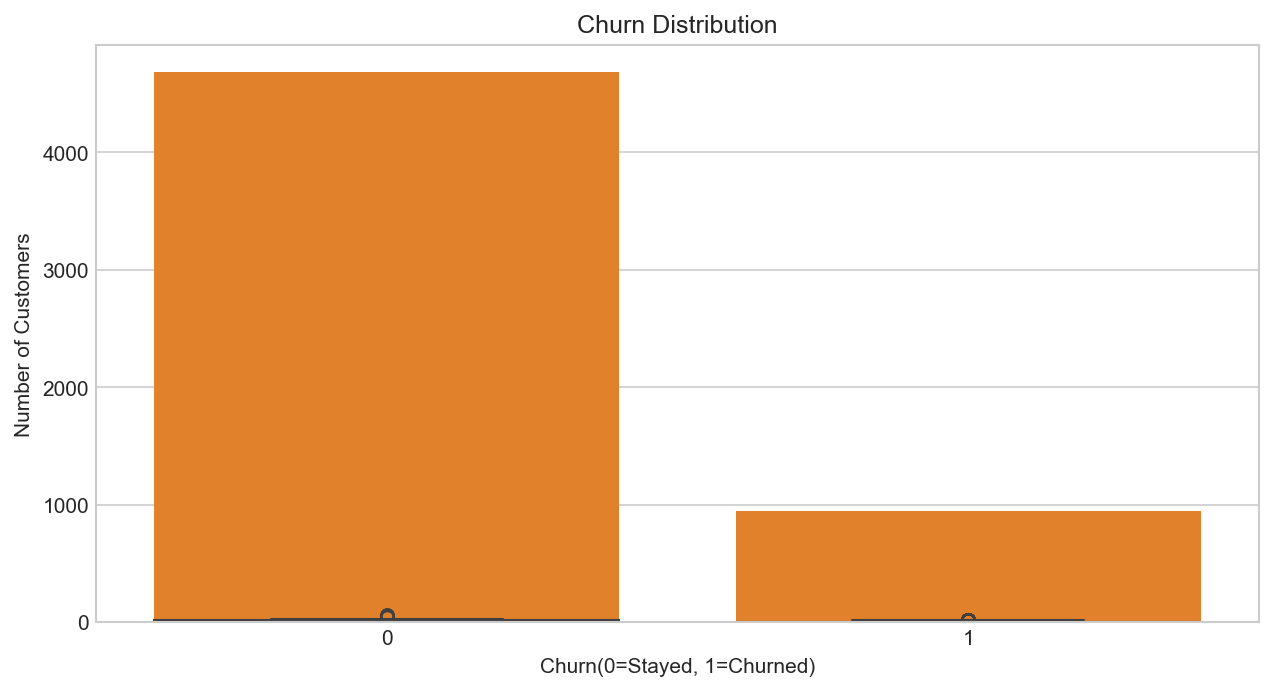

In [52]:
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.xlabel('Churn(0=Stayed, 1=Churned)')
plt.ylabel('Number of Customers')
plt.savefig('churn_distribution.png', dpi=150, bbox_inches='tight')
plt.close()

from IPython.display import Image
Image('churn_distribution.png')

In [33]:
df.select_dtypes(include='object').columns

Index(['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender',
       'PreferedOrderCat', 'MaritalStatus'],
      dtype='object')

In [34]:
le=LabelEncoder()
cat_cols=['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender',
       'PreferedOrderCat', 'MaritalStatus']

for col in cat_cols:
    df[col]=le.fit_transform(df[col])

In [35]:
X=df.drop(columns=['Churn','CustomerID'])
y=df['Churn']

print(X.shape)
print(y.shape)

(5630, 18)
(5630,)


In [36]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train.shape)
print(y_train.shape)

(4504, 18)
(4504,)


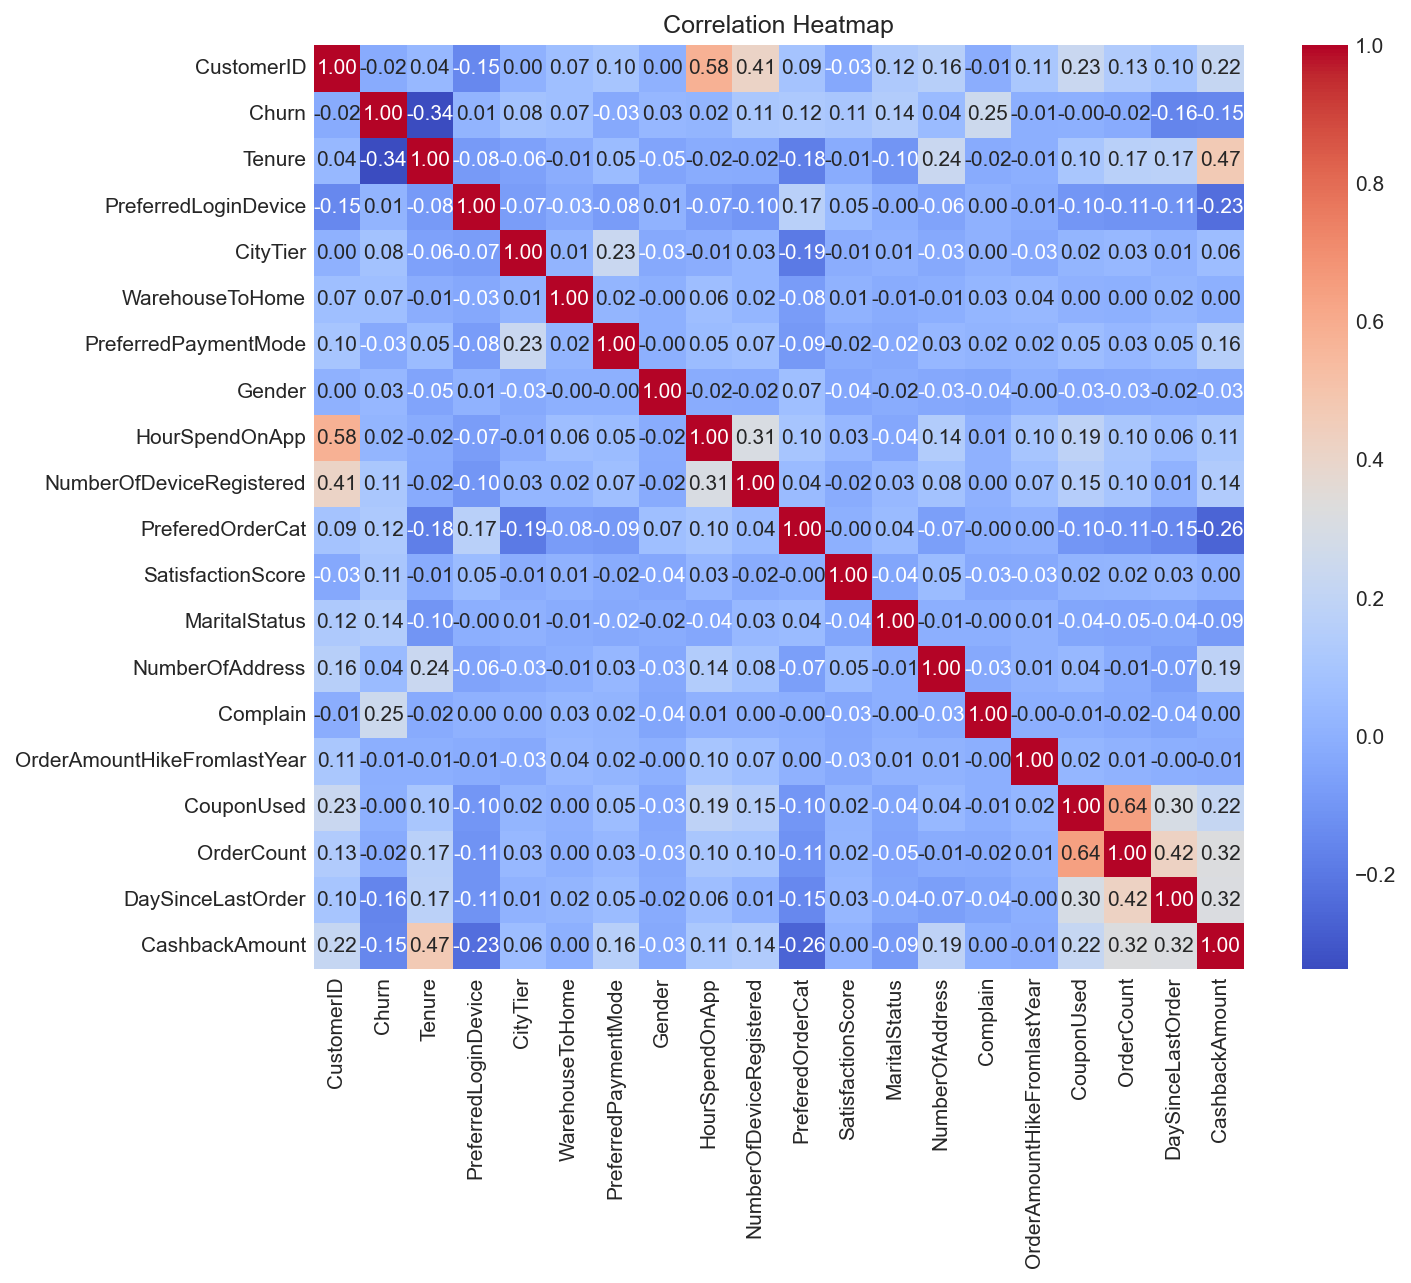

In [51]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.close()

from IPython.display import Image
Image('correlation_heatmap.png')

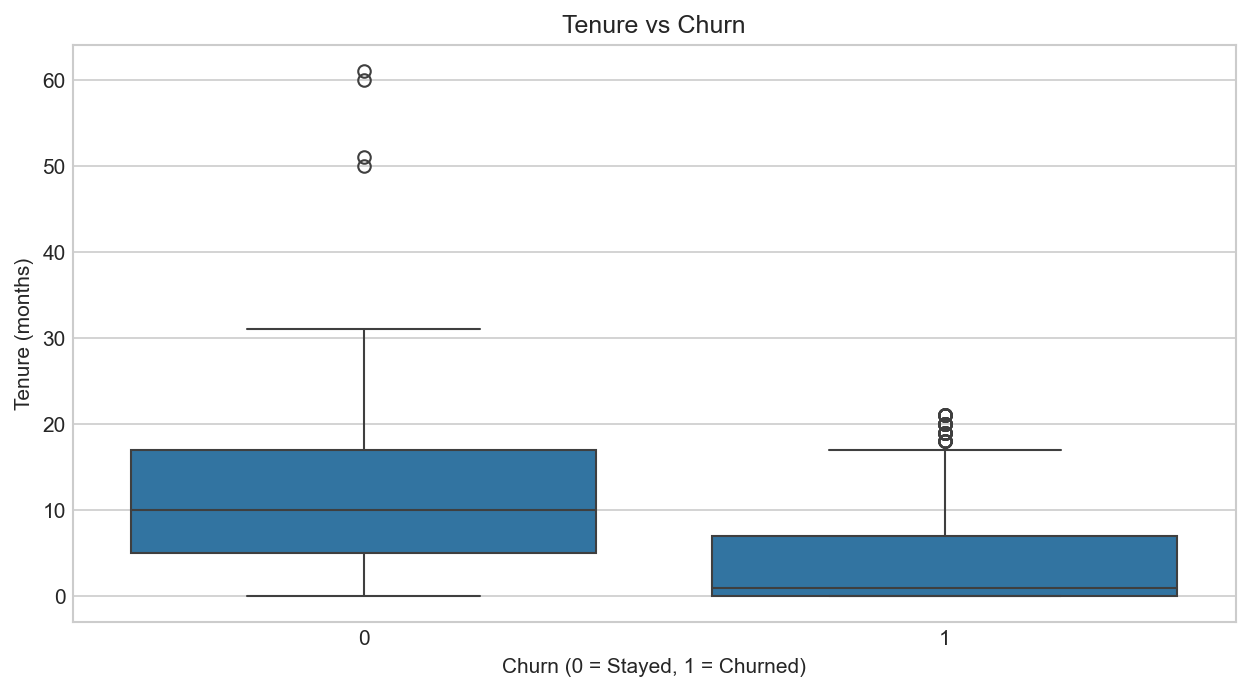

In [50]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='Churn', y='Tenure', data=df)
plt.title('Tenure vs Churn')
plt.xlabel('Churn (0 = Stayed, 1 = Churned)')
plt.ylabel('Tenure (months)')
plt.savefig('tenure_vs_churn.png', dpi=150, bbox_inches='tight')
plt.close()

from IPython.display import Image
Image('tenure_vs_churn.png')

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
colors = ['#1a237e', '#1565c0', '#1976d2', '#42a5f5']

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,classification_report

models={
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(random_state=42)
}

for name,model in models.items():
    model.fit(X_train,y_train)
    y_pred=model.predict(X_test)
    accuracy=accuracy_score(y_test,y_pred)
    print(f'{name}:{accuracy:.4f}')

Logistic Regression:0.8908
Decision Tree:0.9636
Random Forest:0.9831
XGBoost:0.9805


In [41]:
from sklearn.metrics import classification_report
rf_model=models['Random Forest']
y_pred=rf_model.predict(X_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       941
           1       1.00      0.90      0.95       185

    accuracy                           0.98      1126
   macro avg       0.99      0.95      0.97      1126
weighted avg       0.98      0.98      0.98      1126



In [42]:
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle('Customer Churn Prediction - Key Findings', fontsize=20, fontweight='bold', y=1.02)

# 1. Model Accuracy Comparison
models = ['Logistic\nRegression', 'Decision\nTree', 'Random\nForest', 'XGBoost']
accuracies = [89.17, 96.36, 98.31, 98.05]
bars = axes[0,0].bar(models, accuracies, color=['#42a5f5','#1976d2','#1a237e','#1565c0'], edgecolor='white', linewidth=1.5)
axes[0,0].set_title('Model Accuracy Comparison', fontweight='bold', fontsize=13)
axes[0,0].set_ylabel('Accuracy (%)')
axes[0,0].set_ylim(85, 100)
for bar, acc in zip(bars, accuracies):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f'{acc}%', ha='center', fontweight='bold', fontsize=10)

# 2. Churn Distribution Pie Chart
churn_counts = [4682, 948]
labels = ['Stayed (83%)', 'Churned (17%)']
axes[0,1].pie(churn_counts, labels=labels, colors=['#1a237e', '#ef5350'], autopct='%1.1f%%', startangle=90, textprops={'fontsize': 11})
axes[0,1].set_title('Churn Distribution', fontweight='bold', fontsize=13)

# 3. Tenure vs Churn
df.boxplot(column='Tenure', by='Churn', ax=axes[0,2], patch_artist=True,
           boxprops=dict(facecolor='#1976d2', color='#1a237e'),
           medianprops=dict(color='white', linewidth=2))
axes[0,2].set_title('Tenure vs Churn', fontweight='bold', fontsize=13)
axes[0,2].set_xlabel('Churn (0=Stayed, 1=Churned)')
axes[0,2].set_ylabel('Tenure (months)')
plt.sca(axes[0,2])
plt.title('Tenure vs Churn', fontweight='bold', fontsize=13)

# 4. Satisfaction Score vs Churn
sat_churn = df.groupby(['SatisfactionScore', 'Churn']).size().unstack()
sat_churn.plot(kind='bar', ax=axes[1,0], color=['#1a237e', '#ef5350'], edgecolor='white')
axes[1,0].set_title('Satisfaction Score vs Churn', fontweight='bold', fontsize=13)
axes[1,0].set_xlabel('Satisfaction Score')
axes[1,0].set_ylabel('Number of Customers')
axes[1,0].legend(['Stayed', 'Churned'])
axes[1,0].tick_params(axis='x', rotation=0)

# 5. Complain vs Churn
complain_churn = df.groupby(['Complain', 'Churn']).size().unstack()
complain_churn.plot(kind='bar', ax=axes[1,1], color=['#1a237e', '#ef5350'], edgecolor='white')
axes[1,1].set_title('Complaints vs Churn', fontweight='bold', fontsize=13)
axes[1,1].set_xlabel('Complain (0=No, 1=Yes)')
axes[1,1].set_ylabel('Number of Customers')
axes[1,1].legend(['Stayed', 'Churned'])
axes[1,1].tick_params(axis='x', rotation=0)

# 6. Correlation Heatmap
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()[['Churn']].sort_values('Churn', ascending=False).drop('Churn')
sns.heatmap(corr, ax=axes[1,2], annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, cbar=True)
axes[1,2].set_title('Feature Correlation with Churn', fontweight='bold', fontsize=13)

# 7. Feature Importance
feature_names = X.columns.tolist()
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1][:10]
axes[2,0].barh([feature_names[i] for i in indices[::-1]], importances[indices[::-1]], color='#1a237e')
axes[2,0].set_title('Top 10 Feature Importances\n(Random Forest)', fontweight='bold', fontsize=13)
axes[2,0].set_xlabel('Importance Score')
# Hide empty subplots
axes[2,1].axis('off')
axes[2,2].axis('off')

plt.tight_layout()
plt.savefig('churn_findings.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as churn_findings.png!")

Saved as churn_findings.png!


/var/folders/ns/bzyjqsns13s4t1fhv14kb6vr0000gn/T/ipykernel_92748/2098085074.py:67: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


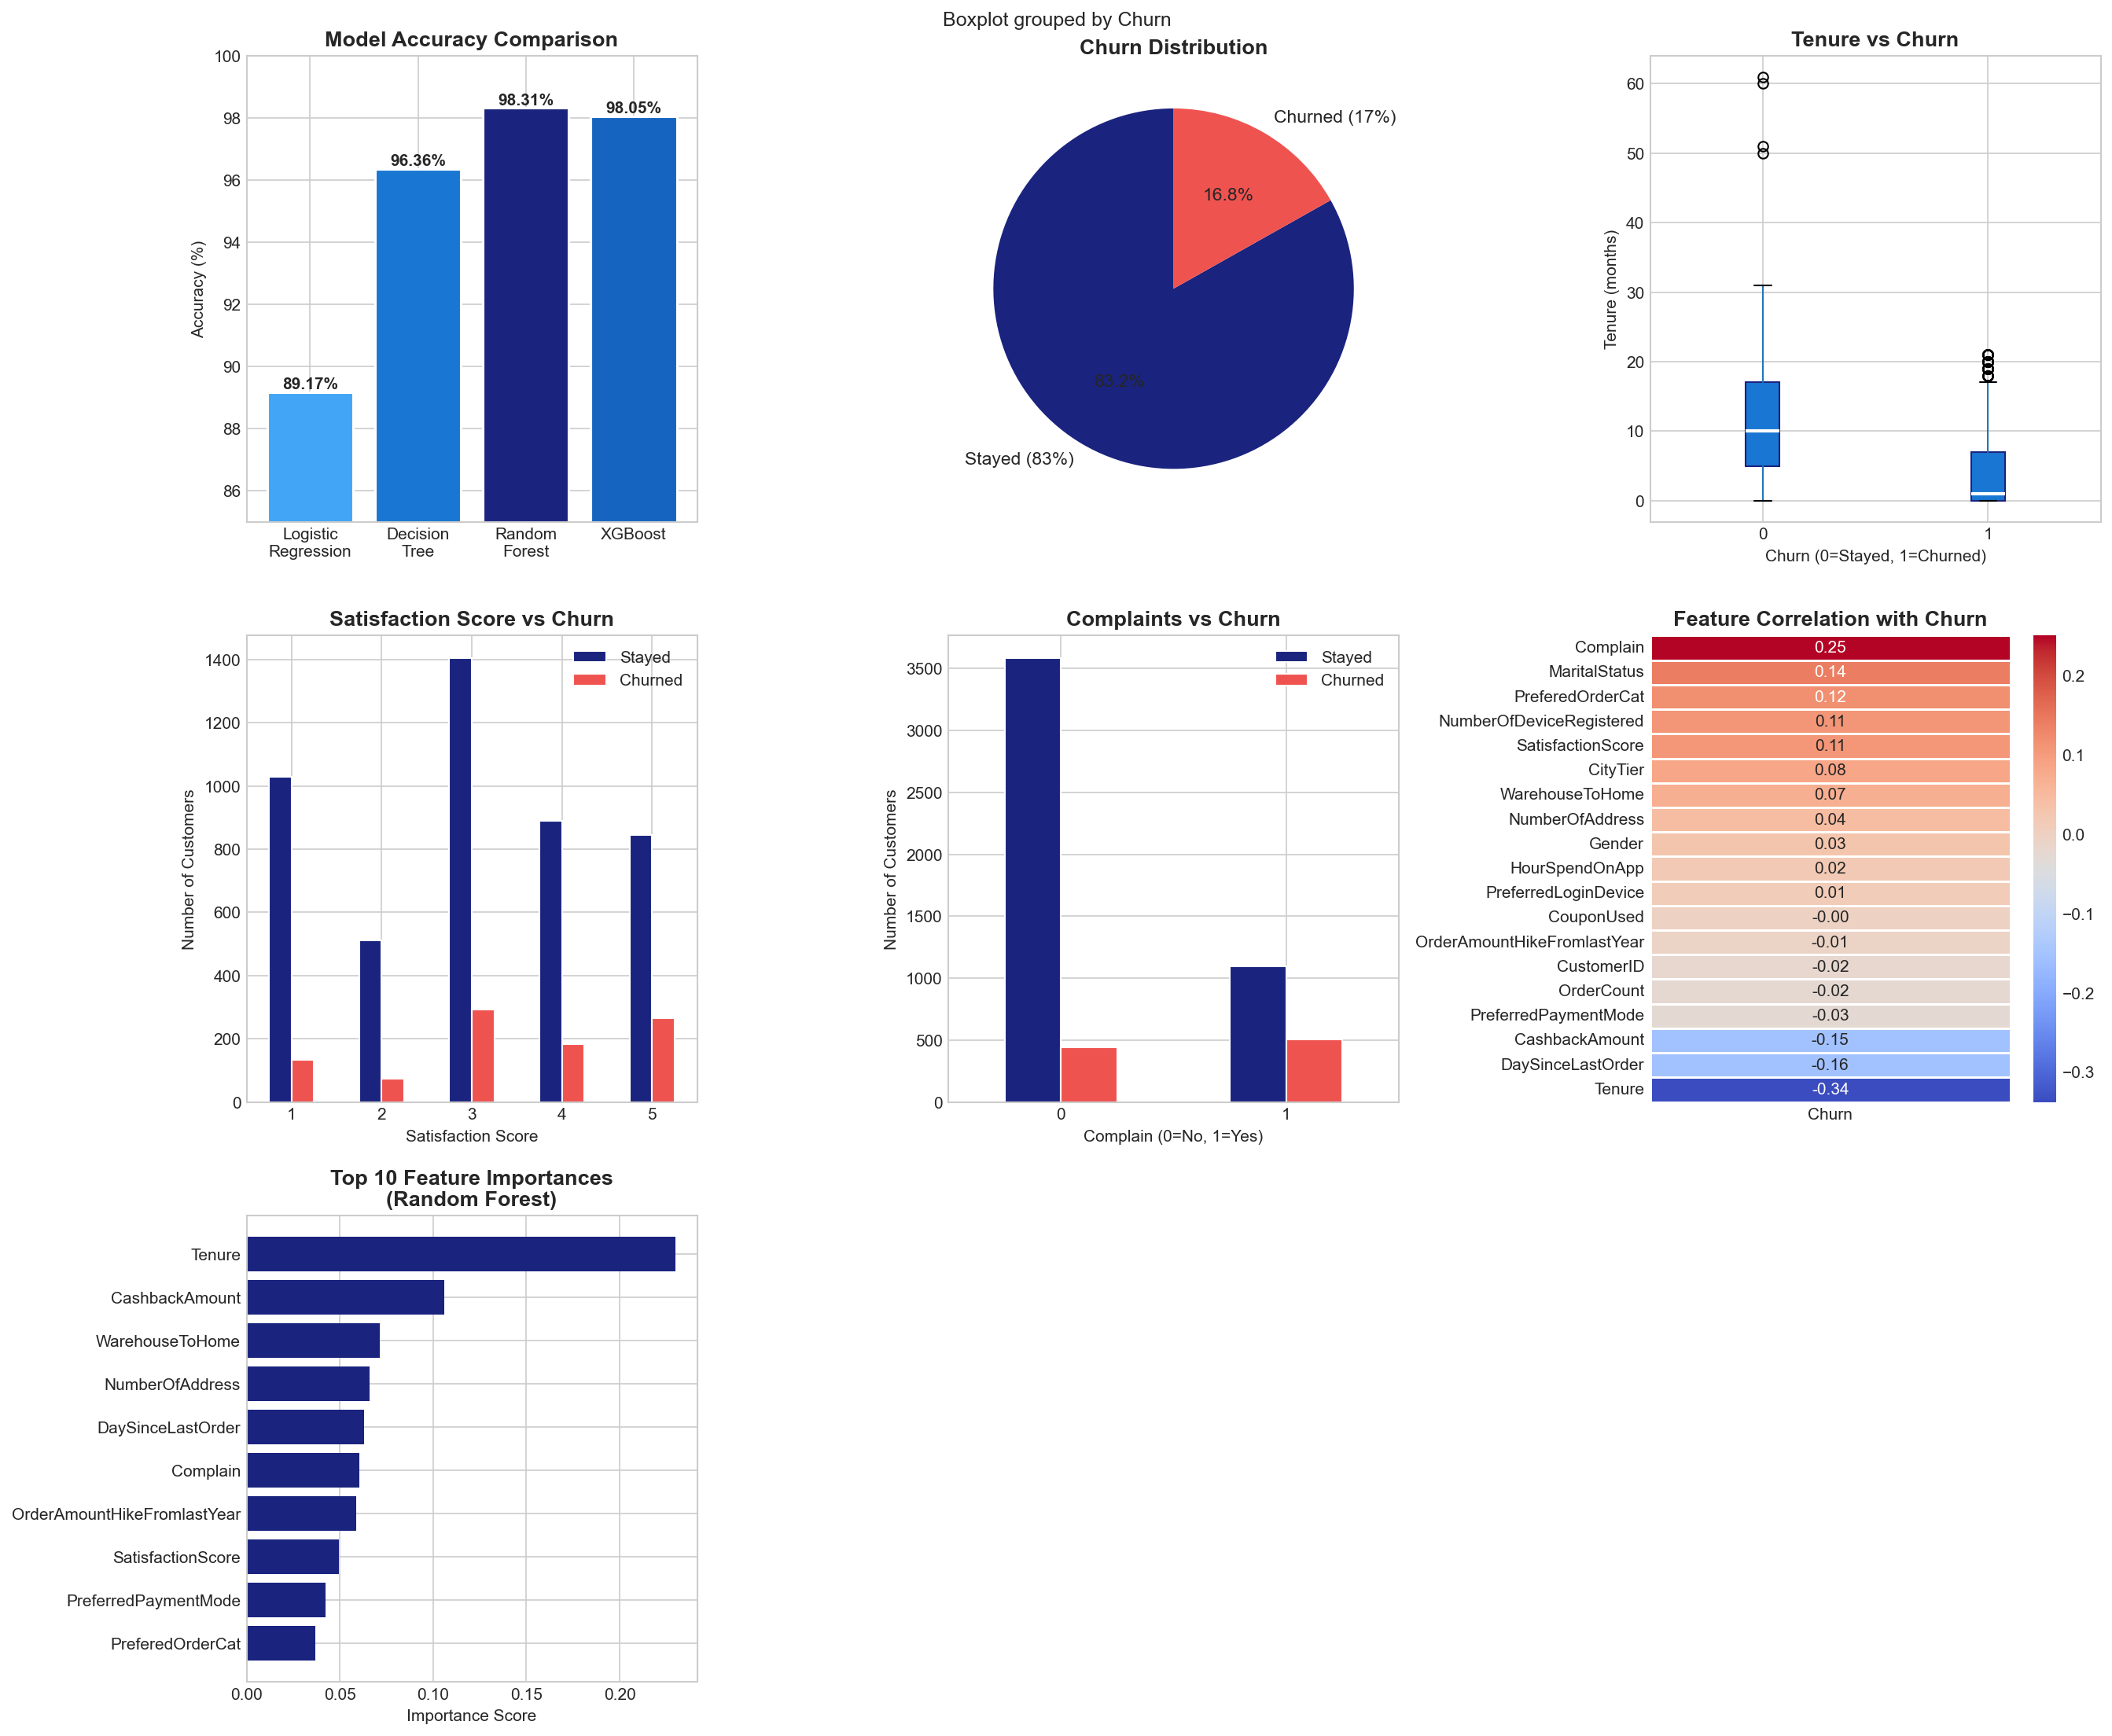

In [43]:
from IPython.display import Image
Image('churn_findings.png')

In [44]:
import pickle

with open('churn_model.pkl','wb') as f:
    pickle.dump(rf_model, f)

print('Model Saved !')

Model Saved !
